#Loading the saved splits

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
BASE_DIR = "/content/drive/MyDrive/Emotion_Recognition_Thesis"

RESULT_DIR = os.path.join(BASE_DIR, "results")
MODEL_DIR = os.path.join(BASE_DIR, "models")
SPLIT_DIR = os.path.join(RESULT_DIR, "dataset_splits")

os.makedirs(MODEL_DIR, exist_ok=True)

train_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "affectnet_train.csv")
)

val_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "affectnet_validation.csv")
)

test_df = pd.read_csv(
    os.path.join(SPLIT_DIR, "affectnet_test.csv")
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 13691
Validation: 2417
Test: 14518


In [ ]:
EMOTION_CLASSES = [
    "anger",
    "contempt",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(EMOTION_CLASSES)

idx_to_class = {
    i: emotion
    for i, emotion in enumerate(EMOTION_CLASSES)
}

#Recreating the transformations

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [ ]:
class FacialEmotionDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["path"]
        ).convert("RGB")

        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
train_dataset = FacialEmotionDataset(
    train_df,
    transform=train_transform
)

val_dataset = FacialEmotionDataset(
    val_df,
    transform=eval_transform
)

test_dataset = FacialEmotionDataset(
    test_df,
    transform=eval_transform
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

#Reusable training function

In [ ]:
from tqdm.auto import tqdm

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, leave=False):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

#Validation function

In [ ]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

#Creating a general training loop with early stopping and checkpoint saving:

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs,
    model_name,
    patience=3
):

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_loss = float("inf")
    patience_counter = 0

    checkpoint_path = os.path.join(
        MODEL_DIR,
        f"{model_name}_best.pth"
    )

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )

        val_loss, val_acc = validate(
            model,
            val_loader,
            criterion,
            device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

            torch.save(
                model.state_dict(),
                checkpoint_path
            )

            print(
                f"Saved best model: {checkpoint_path}"
            )

        else:

            patience_counter += 1

            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    return history

#CNN Baseline

In [ ]:
class CNNBaseline(nn.Module):

    def __init__(self, num_classes=8):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x

#Initializing

In [ ]:
cnn_model = CNNBaseline(
    num_classes=NUM_CLASSES
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    cnn_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print(cnn_model)

CNNBaseline(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

#Training for a sensible first run

In [ ]:
cnn_history = train_model(
    model=cnn_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=15,
    model_name="cnn",
    patience=3
)

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 1/15 | Train Loss: 1.7216 | Train Acc: 0.2963 | Val Loss: 1.5304 | Val Acc: 0.3492
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/cnn_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 2/15 | Train Loss: 1.5289 | Train Acc: 0.3422 | Val Loss: 1.4918 | Val Acc: 0.3678
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/cnn_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

...

  0%|          | 0/428 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionErrorException ignored in: : <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>can only test a child process

Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>    
self._shutdown_workers()Traceback (most recent call last):

  File "/usr/local/lib/pyt

Epoch 9/15 | Train Loss: 1.4797 | Train Acc: 0.3625 | Val Loss: 1.4596 | Val Acc: 0.3761


  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 10/15 | Train Loss: 1.4714 | Train Acc: 0.3648 | Val Loss: 1.4561 | Val Acc: 0.3695
Early stopping triggered.


#Plotting the training Curves

In [ ]:
def plot_history(history, title):

    epochs = range(
        1,
        len(history["train_loss"]) + 1
    )

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_loss"],
        label="Train Loss"
    )

    plt.plot(
        epochs,
        history["val_loss"],
        label="Validation Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))

    plt.plot(
        epochs,
        history["train_acc"],
        label="Train Accuracy"
    )

    plt.plot(
        epochs,
        history["val_acc"],
        label="Validation Accuracy"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.show()

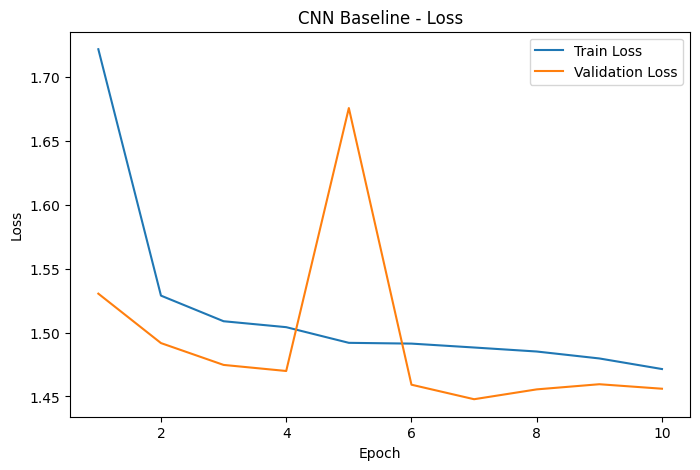

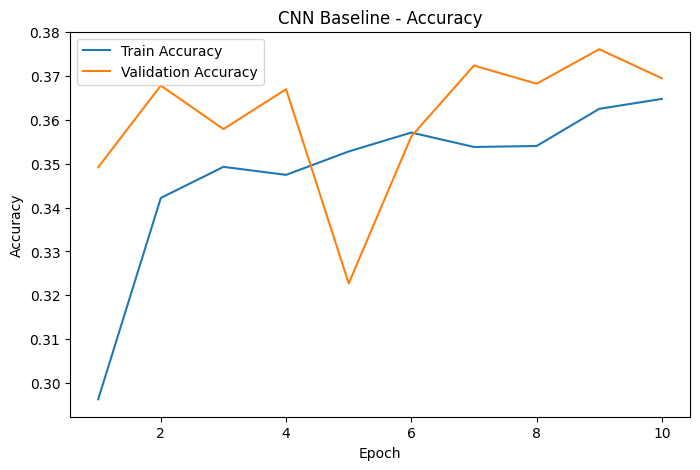

In [ ]:
plot_history(
    cnn_history,
    "CNN Baseline"
)

#Saving Training History

In [ ]:
cnn_history_df = pd.DataFrame(
    cnn_history
)

cnn_history_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "cnn_training_history.csv"
    ),
    index=False
)

#Freeing CNN for GPU memory

In [ ]:
del cnn_model
torch.cuda.empty_cache()

print("GPU cache cleared.")

GPU cache cleared.


#Loading pretrained ResNet50

In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

resnet_weights = ResNet50_Weights.DEFAULT

resnet_model = resnet50(
    weights=resnet_weights
)

print(resnet_model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


Linear(in_features=2048, out_features=1000, bias=True)


In [ ]:
resnet_model.fc = nn.Linear(
    resnet_model.fc.in_features,
    NUM_CLASSES
)

resnet_model = resnet_model.to(device)

print(resnet_model.fc)

Linear(in_features=2048, out_features=8, bias=True)


#Freezing the pretrained backbone

In [ ]:
for param in resnet_model.parameters():
    param.requires_grad = False

for param in resnet_model.fc.parameters():
    param.requires_grad = True

In [ ]:
trainable_params = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in resnet_model.parameters()
)

print("Trainable parameters:", f"{trainable_params:,}")
print("Total parameters:", f"{total_params:,}")

Trainable parameters: 16,392
Total parameters: 23,524,424


#Define loss and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

resnet_optimizer = torch.optim.AdamW(
    resnet_model.fc.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
resnet_stage1_history = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=resnet_optimizer,
    epochs=5,
    model_name="resnet50_stage1",
    patience=3
)

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 1.5624 | Train Acc: 0.4101 | Val Loss: 1.4155 | Val Acc: 0.4779
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_stage1_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 2/5 | Train Loss: 1.3607 | Train Acc: 0.4805 | Val Loss: 1.3580 | Val Acc: 0.4845
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_stage1_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

...

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 1.2621 | Train Acc: 0.5198 | Val Loss: 1.3044 | Val Acc: 0.4977
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_stage1_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 5/5 | Train Loss: 1.2370 | Train Acc: 0.5266 | Val Loss: 1.2982 | Val Acc: 0.5027
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_stage1_best.pth


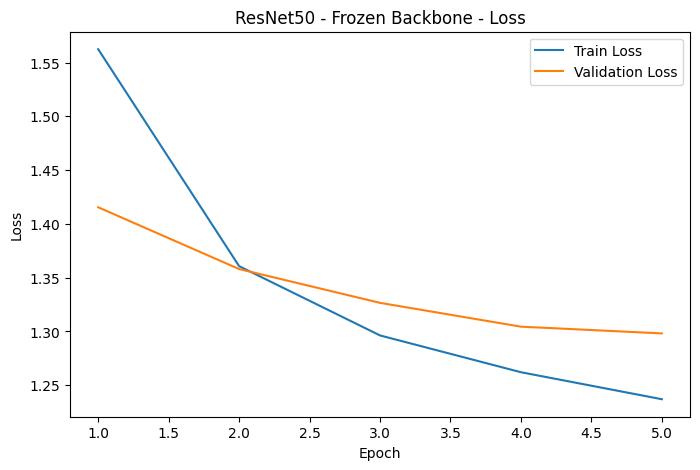

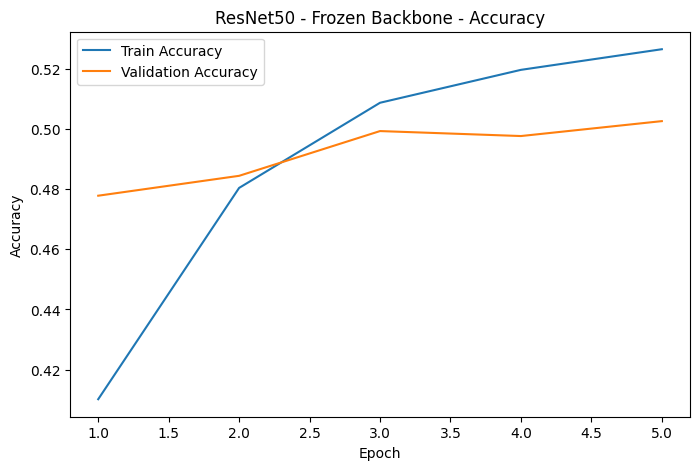

In [ ]:
plot_history(
    resnet_stage1_history,
    "ResNet50 - Frozen Backbone"
)

In [ ]:
pd.DataFrame(
    resnet_stage1_history
).to_csv(
    os.path.join(
        RESULT_DIR,
        "resnet50_stage1_history.csv"
    ),
    index=False
)

#ResNet50 Stage 2 — Fine-tuning

In [ ]:
stage1_path = os.path.join(
    MODEL_DIR,
    "resnet50_stage1_best.pth"
)

resnet_model.load_state_dict(
    torch.load(
        stage1_path,
        map_location=device
    )
)

print("Best Stage-1 model loaded.")

Best Stage-1 model loaded.


#Freezing everything

In [ ]:
for param in resnet_model.parameters():
    param.requires_grad = False

#Unfreezing layer4 and the classifier

In [ ]:
for param in resnet_model.layer4.parameters():
    param.requires_grad = True

for param in resnet_model.fc.parameters():
    param.requires_grad = True

In [ ]:
trainable_params = sum(
    p.numel()
    for p in resnet_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in resnet_model.parameters()
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Percentage trainable:",
    f"{100 * trainable_params / total_params:.2f}%"
)

Trainable parameters: 14,981,128
Total parameters: 23,524,424
Percentage trainable: 63.68%


In [ ]:
criterion = nn.CrossEntropyLoss()

resnet_finetune_optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        resnet_model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

#Fine tuning

In [ ]:
resnet_stage2_history = train_model(
    model=resnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=resnet_finetune_optimizer,
    epochs=8,
    model_name="resnet50_finetuned",
    patience=3
)

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 1/8 | Train Loss: 1.1719 | Train Acc: 0.5544 | Val Loss: 1.2096 | Val Acc: 0.5408
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_finetuned_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 2/8 | Train Loss: 1.1185 | Train Acc: 0.5788 | Val Loss: 1.1737 | Val Acc: 0.5647
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_finetuned_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

...

  0%|          | 0/428 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 7/8 | Train Loss: 0.9315 | Train Acc: 0.6489 | Val Loss: 1.0875 | Val Acc: 0.5941
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_finetuned_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 8/8 | Train Loss: 0.9042 | Train Acc: 0.6689 | Val Loss: 1.0815 | Val Acc: 0.5999
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/resnet50_finetuned_best.pth


#Plotting the fine tune history

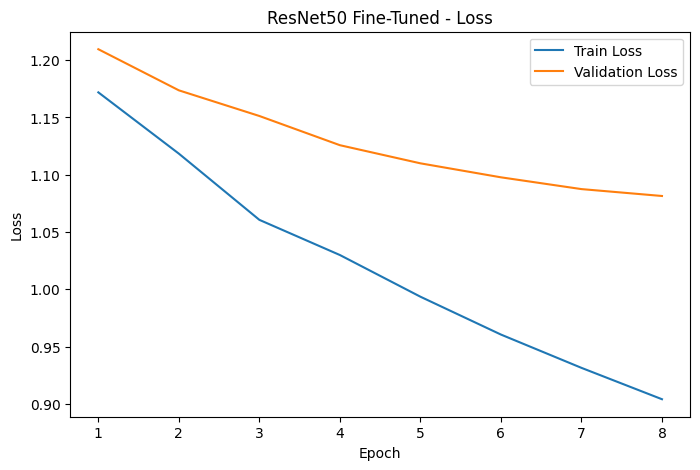

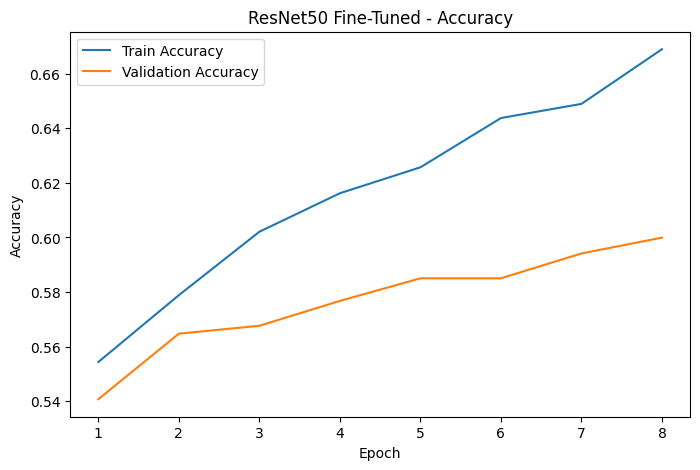

In [ ]:
plot_history(
    resnet_stage2_history,
    "ResNet50 Fine-Tuned"
)

In [ ]:
pd.DataFrame(
    resnet_stage2_history
).to_csv(
    os.path.join(
        RESULT_DIR,
        "resnet50_finetuning_history.csv"
    ),
    index=False
)

In [ ]:
best_resnet_val_acc = max(
    resnet_stage2_history["val_acc"]
)

best_resnet_val_loss = min(
    resnet_stage2_history["val_loss"]
)

best_resnet_epoch = (
    np.argmax(
        resnet_stage2_history["val_acc"]
    ) + 1
)

print(
    f"Best Validation Accuracy: "
    f"{best_resnet_val_acc:.4f}"
)

print(
    f"Best Validation Loss: "
    f"{best_resnet_val_loss:.4f}"
)

print(
    f"Best Accuracy Epoch: "
    f"{best_resnet_epoch}"
)

Best Validation Accuracy: 0.5999
Best Validation Loss: 1.0815
Best Accuracy Epoch: 8


#EfficientNet-B0 — Stage 1

In [ ]:
del resnet_model
torch.cuda.empty_cache()

print("GPU cache cleared.")

GPU cache cleared.


In [ ]:
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

efficientnet_weights = EfficientNet_B0_Weights.DEFAULT

efficientnet_model = efficientnet_b0(
    weights=efficientnet_weights
)

print(efficientnet_model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 122MB/s] 


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


#Replacing the final classifier:

In [ ]:
efficientnet_model.classifier[1] = nn.Linear(
    efficientnet_model.classifier[1].in_features,
    NUM_CLASSES
)

efficientnet_model = efficientnet_model.to(device)

print(efficientnet_model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=8, bias=True)
)


#Freezing the pretrained backbone

In [ ]:
for param in efficientnet_model.parameters():
    param.requires_grad = False

for param in efficientnet_model.classifier.parameters():
    param.requires_grad = True

Verifying

In [ ]:
trainable_params = sum(
    p.numel()
    for p in efficientnet_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in efficientnet_model.parameters()
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

Trainable parameters: 10,248
Total parameters: 4,017,796


#Creating Optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

efficientnet_optimizer = torch.optim.AdamW(
    efficientnet_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

In [ ]:
efficientnet_stage1_history = train_model(
    model=efficientnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=efficientnet_optimizer,
    epochs=5,
    model_name="efficientnet_b0_stage1",
    patience=3
)

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 1/5 | Train Loss: 1.5496 | Train Acc: 0.4085 | Val Loss: 1.4356 | Val Acc: 0.4592
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_stage1_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 2/5 | Train Loss: 1.3951 | Train Acc: 0.4656 | Val Loss: 1.3847 | Val Acc: 0.4766
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_stage1_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

...

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 4/5 | Train Loss: 1.3352 | Train Acc: 0.4863 | Val Loss: 1.3657 | Val Acc: 0.4812
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_stage1_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 5/5 | Train Loss: 1.3275 | Train Acc: 0.4878 | Val Loss: 1.3623 | Val Acc: 0.4857
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_stage1_best.pth


#Saving & Plotting

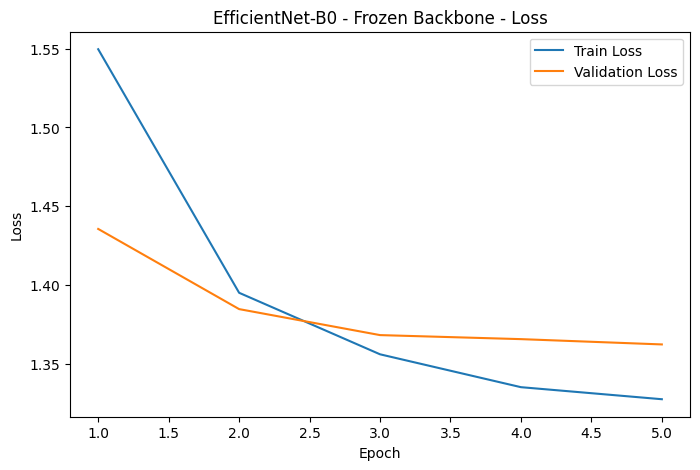

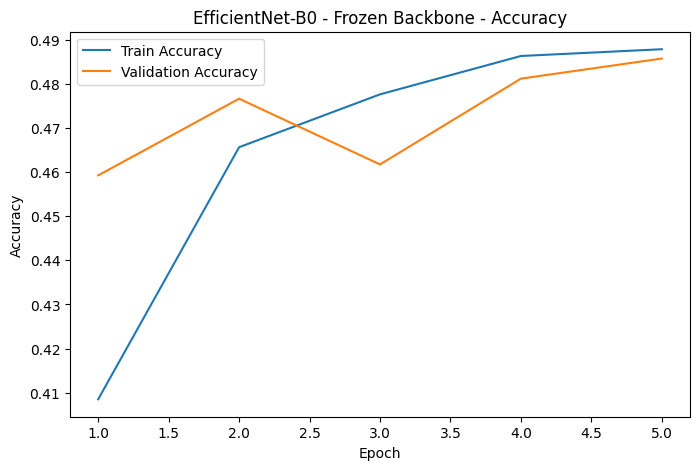

In [ ]:
pd.DataFrame(
    efficientnet_stage1_history
).to_csv(
    os.path.join(
        RESULT_DIR,
        "efficientnet_b0_stage1_history.csv"
    ),
    index=False
)

plot_history(
    efficientnet_stage1_history,
    "EfficientNet-B0 - Frozen Backbone"
)

#Reload the best frozen EfficientNet checkpoint:

In [ ]:
stage1_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_stage1_best.pth"
)

efficientnet_model.load_state_dict(
    torch.load(
        stage1_path,
        map_location=device
    )
)

print("Best EfficientNet Stage-1 model loaded.")

Best EfficientNet Stage-1 model loaded.


#Freezing everything

In [ ]:
for param in efficientnet_model.parameters():
    param.requires_grad = False

#Unfreezing last feature block & Classifier

In [ ]:
for param in efficientnet_model.features[-1].parameters():
    param.requires_grad = True

for param in efficientnet_model.classifier.parameters():
    param.requires_grad = True

In [ ]:
trainable_params = sum(
    p.numel()
    for p in efficientnet_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in efficientnet_model.parameters()
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Percentage trainable:",
    f"{100 * trainable_params / total_params:.2f}%"
)

Trainable parameters: 422,408
Total parameters: 4,017,796
Percentage trainable: 10.51%


In [ ]:
criterion = nn.CrossEntropyLoss()

efficientnet_finetune_optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        efficientnet_model.parameters()
    ),
    lr=1e-5,
    weight_decay=1e-4
)

In [ ]:
efficientnet_stage2_history = train_model(
    model=efficientnet_model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=efficientnet_finetune_optimizer,
    epochs=8,
    model_name="efficientnet_b0_finetuned",
    patience=3
)

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 1/8 | Train Loss: 1.3055 | Train Acc: 0.5003 | Val Loss: 1.3515 | Val Acc: 0.4866
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_finetuned_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 2/8 | Train Loss: 1.2919 | Train Acc: 0.5045 | Val Loss: 1.3391 | Val Acc: 0.4849
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_finetuned_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

...

  0%|          | 0/428 [00:00<?, ?it/s]

Epoch 7/8 | Train Loss: 1.2714 | Train Acc: 0.5207 | Val Loss: 1.3153 | Val Acc: 0.4981
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_finetuned_best.pth


  0%|          | 0/428 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7db21dbb20c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 8/8 | Train Loss: 1.2602 | Train Acc: 0.5226 | Val Loss: 1.3102 | Val Acc: 0.4969
Saved best model: /content/drive/MyDrive/Emotion_Recognition_Thesis/models/efficientnet_b0_finetuned_best.pth


#Plotting & Saving the history

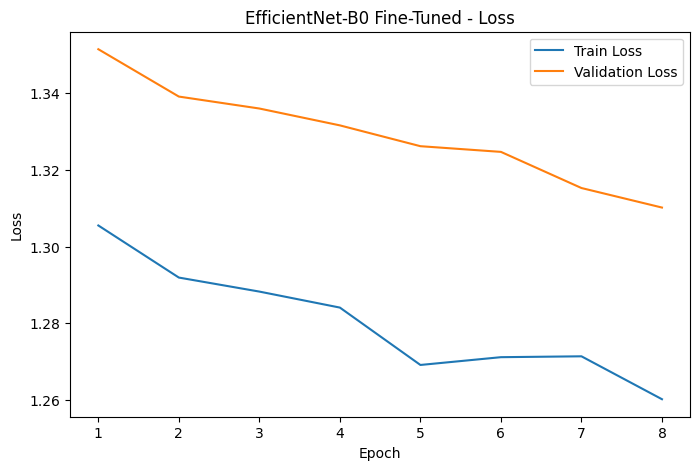

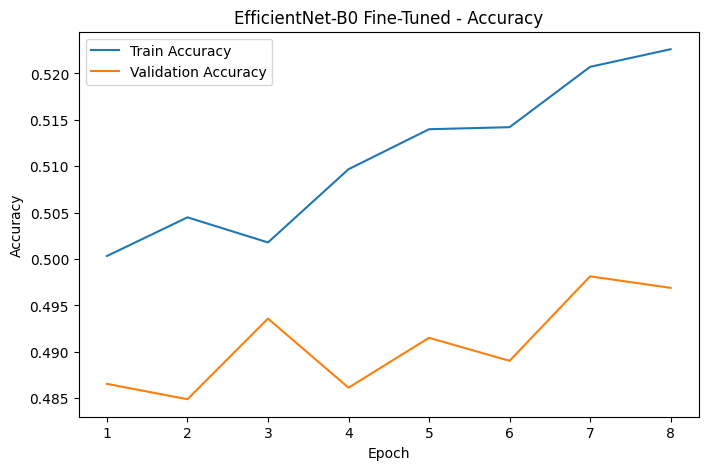

In [ ]:
plot_history(
    efficientnet_stage2_history,
    "EfficientNet-B0 Fine-Tuned"
)

pd.DataFrame(
    efficientnet_stage2_history
).to_csv(
    os.path.join(
        RESULT_DIR,
        "efficientnet_b0_finetuning_history.csv"
    ),
    index=False
)

#Extracting Best Results

In [ ]:
best_eff_val_acc = max(
    efficientnet_stage2_history["val_acc"]
)

best_eff_val_loss = min(
    efficientnet_stage2_history["val_loss"]
)

best_eff_epoch = (
    np.argmax(
        efficientnet_stage2_history["val_acc"]
    ) + 1
)

print(
    f"Best Validation Accuracy: "
    f"{best_eff_val_acc:.4f}"
)

print(
    f"Best Validation Loss: "
    f"{best_eff_val_loss:.4f}"
)

print(
    f"Best Accuracy Epoch: "
    f"{best_eff_epoch}"
)

Best Validation Accuracy: 0.4981
Best Validation Loss: 1.3102
Best Accuracy Epoch: 7


**Key Points**:

  In this notebook, I have trained all the three models:

    1.CNN Baesline

    2.ResNet50
    
    3.EfficientNet-B0

    4.Fine Tuning